In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv('predictive_maintenance.csv')

In [3]:
df.shape

(10000, 10)

In [4]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [6]:
from ydata_profiling import ProfileReport

In [7]:
profile = ProfileReport(
    df,  
    title="Full Interaction Report"
)

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [10]:
cols_to_drop = ['UDI', 'Product ID', 'Target', 'Failure Type']
X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['Failure Type']

# Feature Engineering
X = pd.get_dummies(X, columns=['Type'])
X['Temp_Diff'] = X['Process temperature [K]'] - X['Air temperature [K]']
X['Power'] = X['Rotational speed [rpm]'] * X['Torque [Nm]']
X['Strain'] = X['Tool wear [min]'] * X['Torque [Nm]']


In [11]:
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,298.1,308.6,1551,42.8,0
1,298.2,308.7,1408,46.3,3
2,298.1,308.5,1498,49.4,5
3,298.2,308.6,1433,39.5,7
4,298.2,308.7,1408,40.0,9


In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [13]:
le = LabelEncoder()

In [14]:
y = pd.DataFrame(y)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Check class distribution in training set
print("Training set class distribution:")
print(y_train.value_counts())

Training set class distribution:
Failure Type            
No Failure                  7722
Heat Dissipation Failure      90
Power Failure                 76
Overstrain Failure            62
Tool Wear Failure             36
Random Failures               14
Name: count, dtype: int64


In [16]:
# Apply LabelEncoder to target
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(f"Classes encoded: {le.classes_}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Classes encoded: ['Heat Dissipation Failure' 'No Failure' 'Overstrain Failure'
 'Power Failure' 'Random Failures' 'Tool Wear Failure']

Features scaled successfully!
X_train_scaled shape: (8000, 5)
X_test_scaled shape: (2000, 5)


c:\Users\priya\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\priya\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [17]:
# We will use Random Forest's class_weight='balanced_subsample' instead of SMOTE
# This is often better for extreme tabular imbalances
X_train_resampled = X_train_scaled
y_train_resampled = y_train_encoded

Original training set distribution:
Counter({np.int64(1): 7722, np.int64(0): 90, np.int64(3): 76, np.int64(2): 62, np.int64(5): 36, np.int64(4): 14})

Resampled training set distribution (after SMOTE):
Counter({np.int64(1): 7722, np.int64(5): 7722, np.int64(4): 7722, np.int64(3): 7722, np.int64(0): 7722, np.int64(2): 7722})

Total samples after SMOTE: 46332


In [18]:
# Train an optimized Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)
print("Optimized Random Forest model trained successfully!")

Random Forest model trained successfully!


Accuracy: 0.8460
Macro F1: 0.5215
Weighted F1: 0.9037


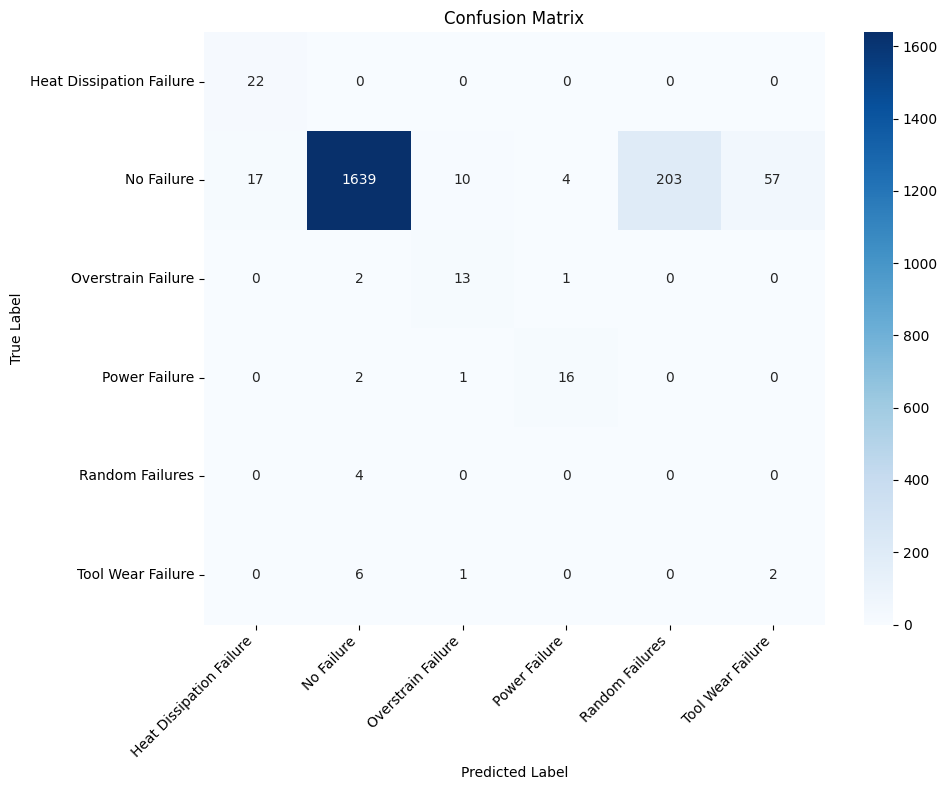


Classification Report:
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.56      1.00      0.72        22
              No Failure       0.99      0.85      0.91      1930
      Overstrain Failure       0.52      0.81      0.63        16
           Power Failure       0.76      0.84      0.80        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.03      0.22      0.06         9

                accuracy                           0.85      2000
               macro avg       0.48      0.62      0.52      2000
            weighted avg       0.97      0.85      0.90      2000



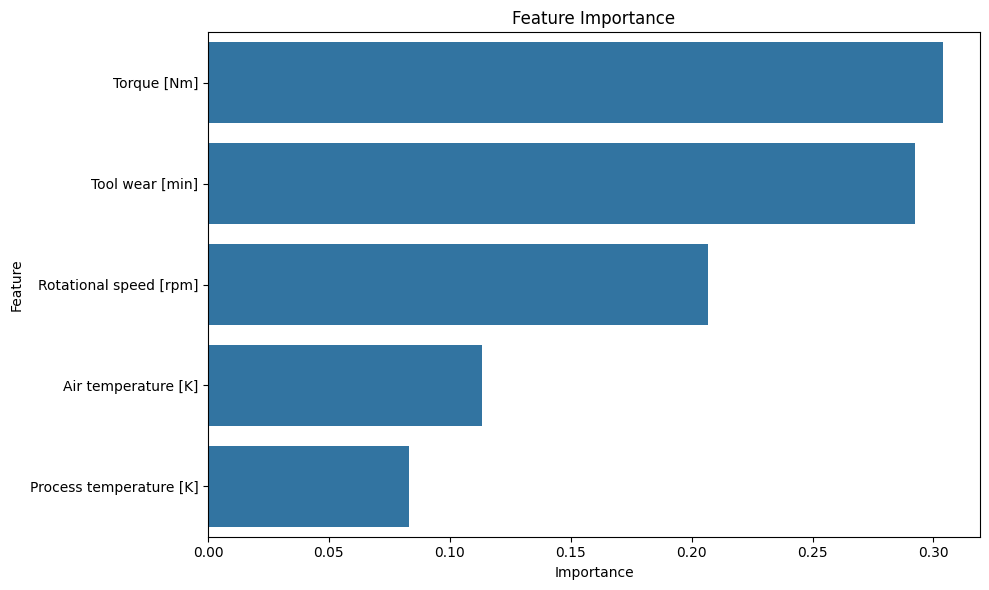


Feature Importance:
                   Feature  Importance
3              Torque [Nm]    0.304052
4          Tool wear [min]    0.292328
2   Rotational speed [rpm]    0.206825
0      Air temperature [K]    0.113497
1  Process temperature [K]    0.083298


In [19]:
# Evaluate the model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions on test set
y_pred = rf_model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {f1_score(y_test_encoded, y_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test_encoded, y_pred, average='weighted'):.4f}")

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

# Feature Importance
plt.figure(figsize=(10, 6))
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

print("\nFeature Importance:")
print(feature_importance)